In [2]:
import pandas as pd
import requests as req
import numpy
import matplotlib.pyplot as plt
import statistics
import seaborn as sns
from scipy.stats import kurtosis

In [10]:
# from_date = input("enter from year and month hypen separated:")
# to_date = input("enter to year and month hypen separated:")

power_generation_url = f"https://api.ember-energy.org/v1/electricity-generation/monthly?entity_code=IND&is_aggregate_entity=false&start_date=2023-01&end_date=2026-01&is_aggregate_series=false&include_all_dates_value_range=false&api_key=088df4ed-46ea-a471-791b-22fdc4eeea29"
json_repsonse = req.get(power_generation_url)
print(json_repsonse.json()['data'])
power_df = pd.DataFrame(json_repsonse.json()['data'])
# power_df['updated_on'] = pd.to_datetime(power_df['updated_on'], unit='ms')
print(power_df[['entity', 'entity_code', 'date', 'series', 'generation_twh']])

[{'entity': 'India', 'entity_code': 'IND', 'is_aggregate_entity': False, 'date': '2023-01-01', 'series': 'Bioenergy', 'is_aggregate_series': False, 'generation_twh': 2.59, 'share_of_generation_pct': 1.89}, {'entity': 'India', 'entity_code': 'IND', 'is_aggregate_entity': False, 'date': '2023-01-01', 'series': 'Coal', 'is_aggregate_series': False, 'generation_twh': 104.48, 'share_of_generation_pct': 76.17}, {'entity': 'India', 'entity_code': 'IND', 'is_aggregate_entity': False, 'date': '2023-01-01', 'series': 'Gas', 'is_aggregate_series': False, 'generation_twh': 1.88, 'share_of_generation_pct': 1.37}, {'entity': 'India', 'entity_code': 'IND', 'is_aggregate_entity': False, 'date': '2023-01-01', 'series': 'Hydro', 'is_aggregate_series': False, 'generation_twh': 8.7, 'share_of_generation_pct': 6.34}, {'entity': 'India', 'entity_code': 'IND', 'is_aggregate_entity': False, 'date': '2023-01-01', 'series': 'Net imports', 'is_aggregate_series': False, 'generation_twh': -1.0, 'share_of_generatio

In [11]:
wind_df = power_df.loc[(power_df['series'] == 'Wind') & (power_df['generation_twh'] != 0)]
print(wind_df[['entity', 'entity_code', 'date', 'series', 'generation_twh']])


    entity entity_code        date series  generation_twh
9    India         IND  2023-01-01   Wind            5.01
19   India         IND  2023-02-01   Wind            3.13
29   India         IND  2023-03-01   Wind            4.14
39   India         IND  2023-04-01   Wind            4.25
49   India         IND  2023-05-01   Wind            8.12
59   India         IND  2023-06-01   Wind           11.56
69   India         IND  2023-07-01   Wind           12.45
79   India         IND  2023-08-01   Wind           12.39
89   India         IND  2023-09-01   Wind            8.85
99   India         IND  2023-10-01   Wind            3.55
109  India         IND  2023-11-01   Wind            3.54
119  India         IND  2023-12-01   Wind            5.11
129  India         IND  2024-01-01   Wind            4.08
139  India         IND  2024-02-01   Wind            4.91
149  India         IND  2024-03-01   Wind            4.58
159  India         IND  2024-04-01   Wind            4.73
169  India    

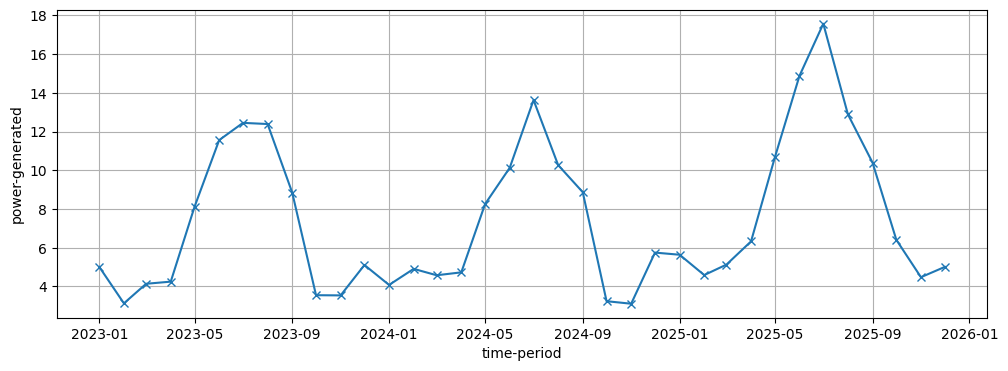

In [12]:
wind_fig = plt.figure()
wind_fig.set_figwidth(12)
wind_fig.set_figheight(4)

x_axis_points = numpy.array(pd.DatetimeIndex(wind_df['date']))
y_axis_points = numpy.array(wind_df['generation_twh'])

plt.xlabel('time-period')
plt.ylabel('power-generated')

# plt.bar(x_axis_points, y_axis_points, color="green")
plt.plot(x_axis_points, y_axis_points, marker = 'x')
plt.grid()


In [15]:
thermal_df = power_df.loc[(power_df['series'] == 'Coal') & (power_df['generation_twh'] != 0)]
print(thermal_df[['entity', 'entity_code', 'date', 'series', 'generation_twh']])

    entity entity_code        date series  generation_twh
1    India         IND  2023-01-01   Coal          104.48
11   India         IND  2023-02-01   Coal           97.58
21   India         IND  2023-03-01   Coal          106.46
31   India         IND  2023-04-01   Coal          109.10
41   India         IND  2023-05-01   Coal          108.65
51   India         IND  2023-06-01   Coal          106.16
61   India         IND  2023-07-01   Coal          100.91
71   India         IND  2023-08-01   Coal          106.41
81   India         IND  2023-09-01   Coal          105.83
91   India         IND  2023-10-01   Coal          114.00
101  India         IND  2023-11-01   Coal          101.99
111  India         IND  2023-12-01   Coal          103.54
121  India         IND  2024-01-01   Coal          114.93
131  India         IND  2024-02-01   Coal          106.99
141  India         IND  2024-03-01   Coal          116.35
151  India         IND  2024-04-01   Coal          119.92
161  India    

[]

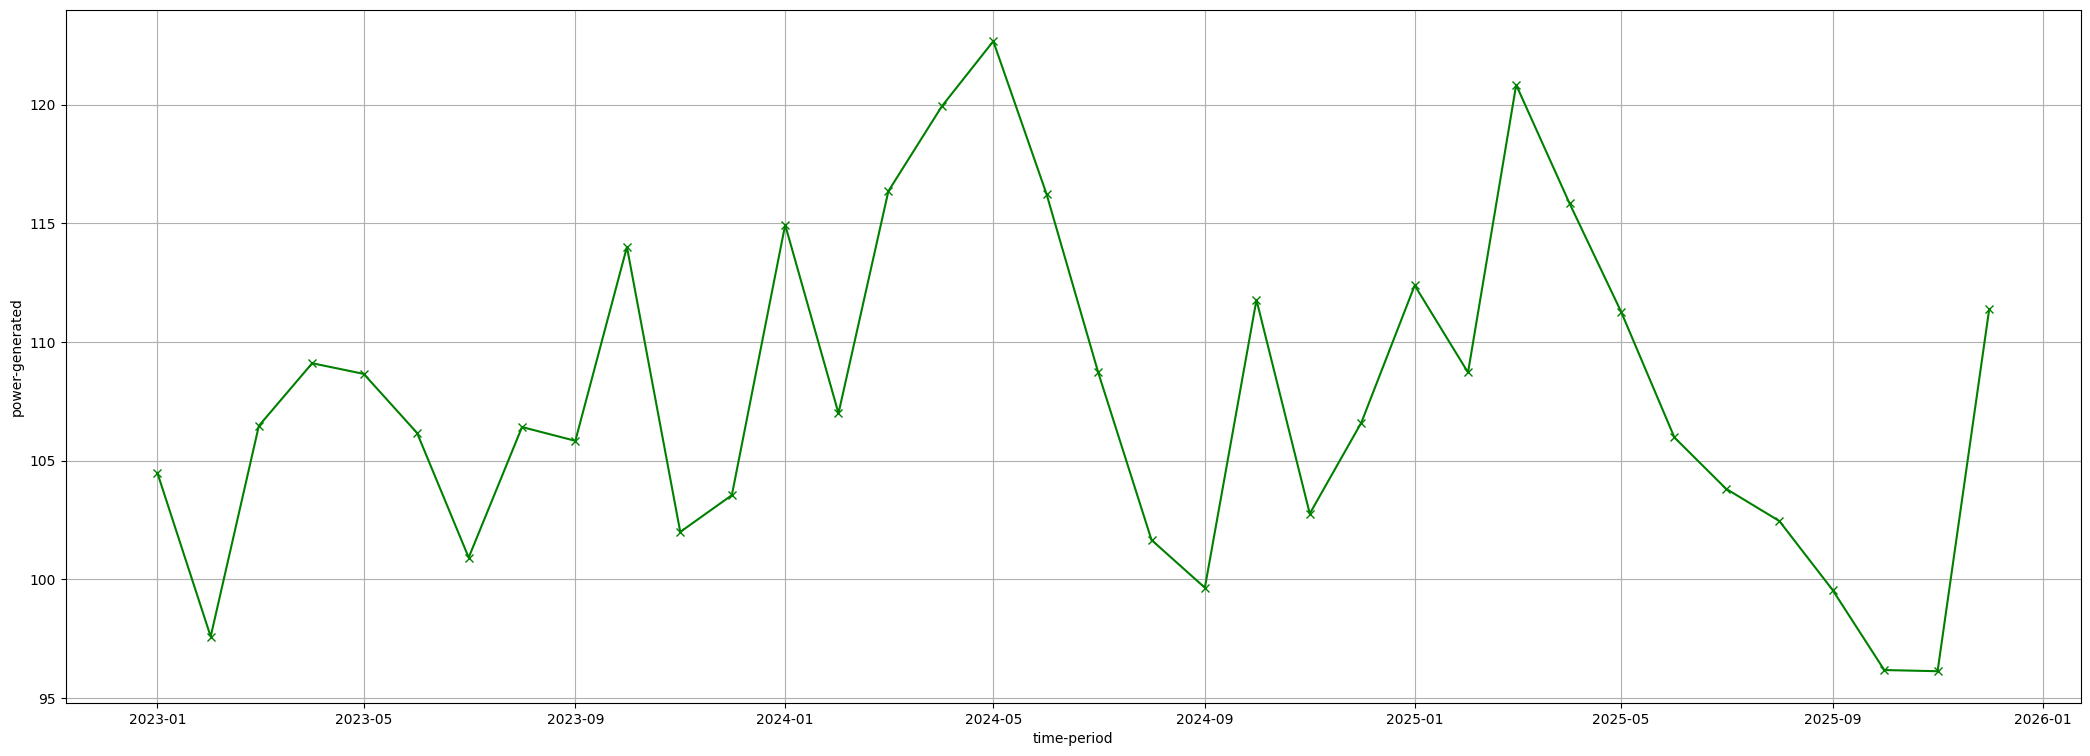

In [17]:
thermal_fig = plt.figure()
thermal_fig.set_figwidth(26)
thermal_fig.set_figheight(9)

x_axis_points = numpy.array(pd.DatetimeIndex(thermal_df['date']))
y_axis_points = numpy.array(thermal_df['generation_twh'])

plt.xlabel('time-period')
plt.ylabel('power-generated')

# plt.bar(x_axis_points, y_axis_points)
plt.plot(x_axis_points, y_axis_points, color='green', marker = 'x')
plt.grid()
plt.plot()

In [18]:
hydro_df = power_df.loc[(power_df['series'] == 'Hydro') & (power_df['generation_twh'] != 0)]
print(hydro_df[['entity', 'entity_code', 'date', 'series', 'generation_twh']])

    entity entity_code        date series  generation_twh
3    India         IND  2023-01-01  Hydro            8.70
13   India         IND  2023-02-01  Hydro            8.92
23   India         IND  2023-03-01  Hydro            8.35
33   India         IND  2023-04-01  Hydro            9.32
43   India         IND  2023-05-01  Hydro           12.19
53   India         IND  2023-06-01  Hydro           15.07
63   India         IND  2023-07-01  Hydro           19.17
73   India         IND  2023-08-01  Hydro           23.20
83   India         IND  2023-09-01  Hydro           17.54
93   India         IND  2023-10-01  Hydro           12.21
103  India         IND  2023-11-01  Hydro            7.40
113  India         IND  2023-12-01  Hydro            6.76
123  India         IND  2024-01-01  Hydro            6.84
133  India         IND  2024-02-01  Hydro            6.37
143  India         IND  2024-03-01  Hydro            7.48
153  India         IND  2024-04-01  Hydro            8.72
163  India    

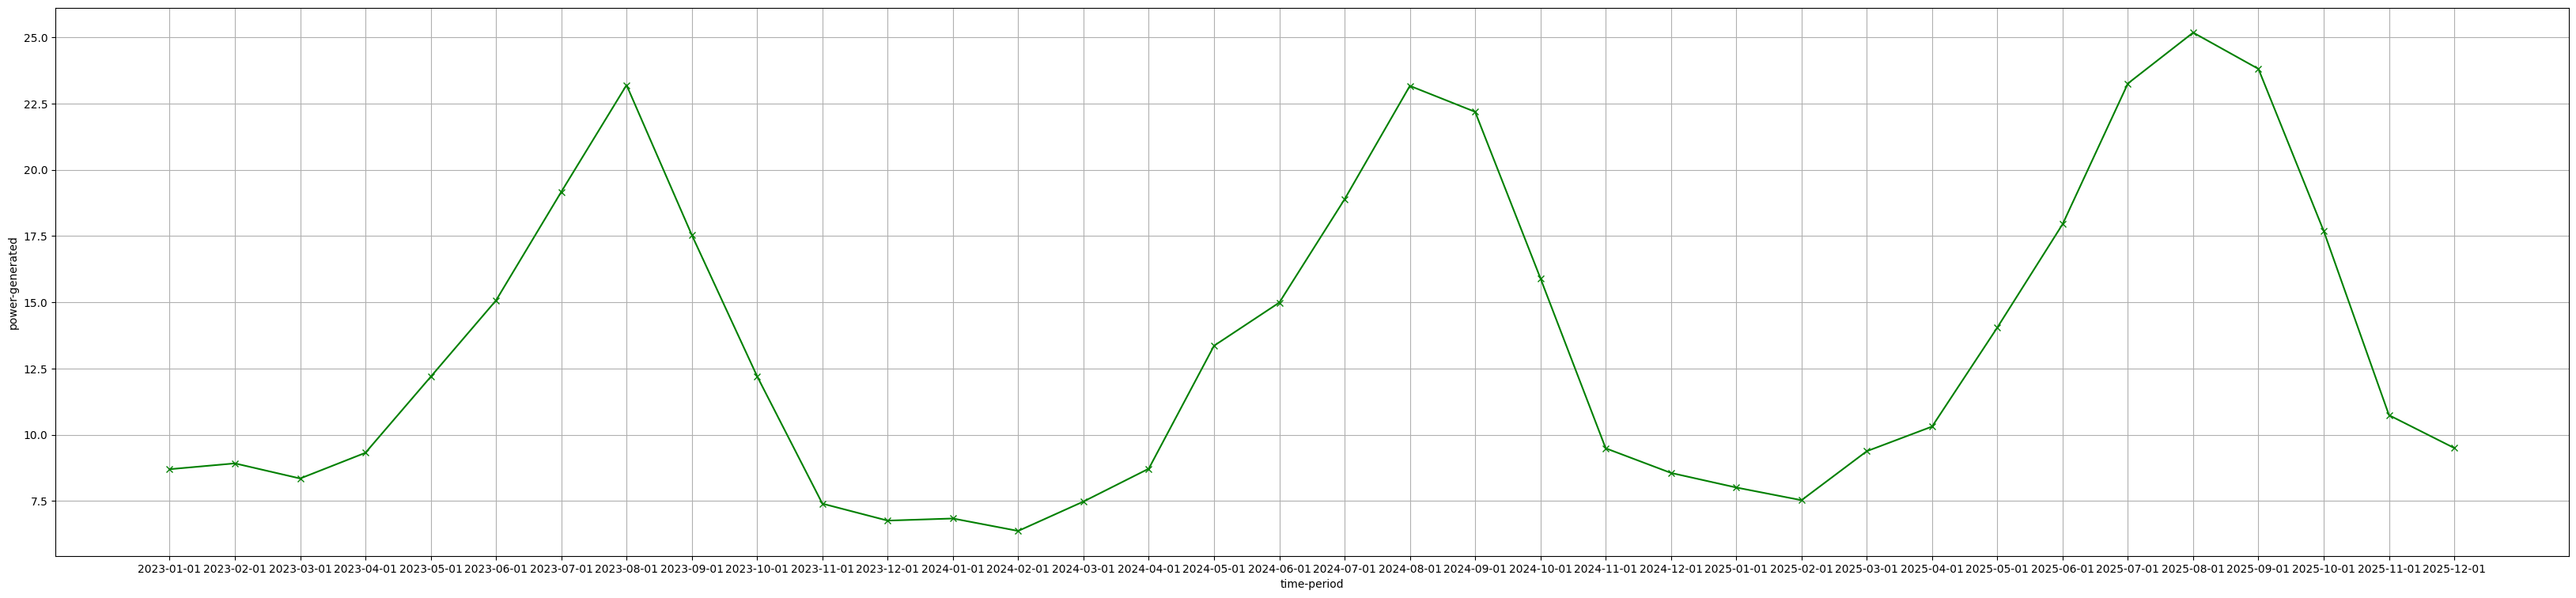

In [19]:
hydro_fig = plt.figure()
hydro_fig.set_figwidth(41)
hydro_fig.set_figheight(9)

x_axis_points = numpy.array(hydro_df['date'])
y_axis_points = numpy.array(hydro_df['generation_twh'])

plt.xlabel('time-period')
plt.ylabel('power-generated')

# plt.bar(x_axis_points, y_axis_points)
plt.plot(x_axis_points, y_axis_points, color='green', marker = 'x')
plt.grid()


In [20]:
solar_df = power_df.loc[(power_df['series'] == 'Solar') & (power_df['generation_twh'] != 0)]
print(solar_df[['entity', 'entity_code', 'date', 'series', 'generation_twh']])

    entity entity_code        date series  generation_twh
8    India         IND  2023-01-01  Solar           10.16
18   India         IND  2023-02-01  Solar           10.43
28   India         IND  2023-03-01  Solar           11.46
38   India         IND  2023-04-01  Solar           11.10
48   India         IND  2023-05-01  Solar           12.16
58   India         IND  2023-06-01  Solar           10.89
68   India         IND  2023-07-01  Solar            9.13
78   India         IND  2023-08-01  Solar            9.94
88   India         IND  2023-09-01  Solar            9.87
98   India         IND  2023-10-01  Solar           11.71
108  India         IND  2023-11-01  Solar            8.87
118  India         IND  2023-12-01  Solar            9.80
128  India         IND  2024-01-01  Solar           10.09
138  India         IND  2024-02-01  Solar           11.69
148  India         IND  2024-03-01  Solar           14.66
158  India         IND  2024-04-01  Solar           13.93
168  India    

In [31]:
solar_df = power_df.loc[(power_df['series'] == 'Solar') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2026)]
print(statistics.stdev(solar_df['generation_twh']))

2.188125148767014


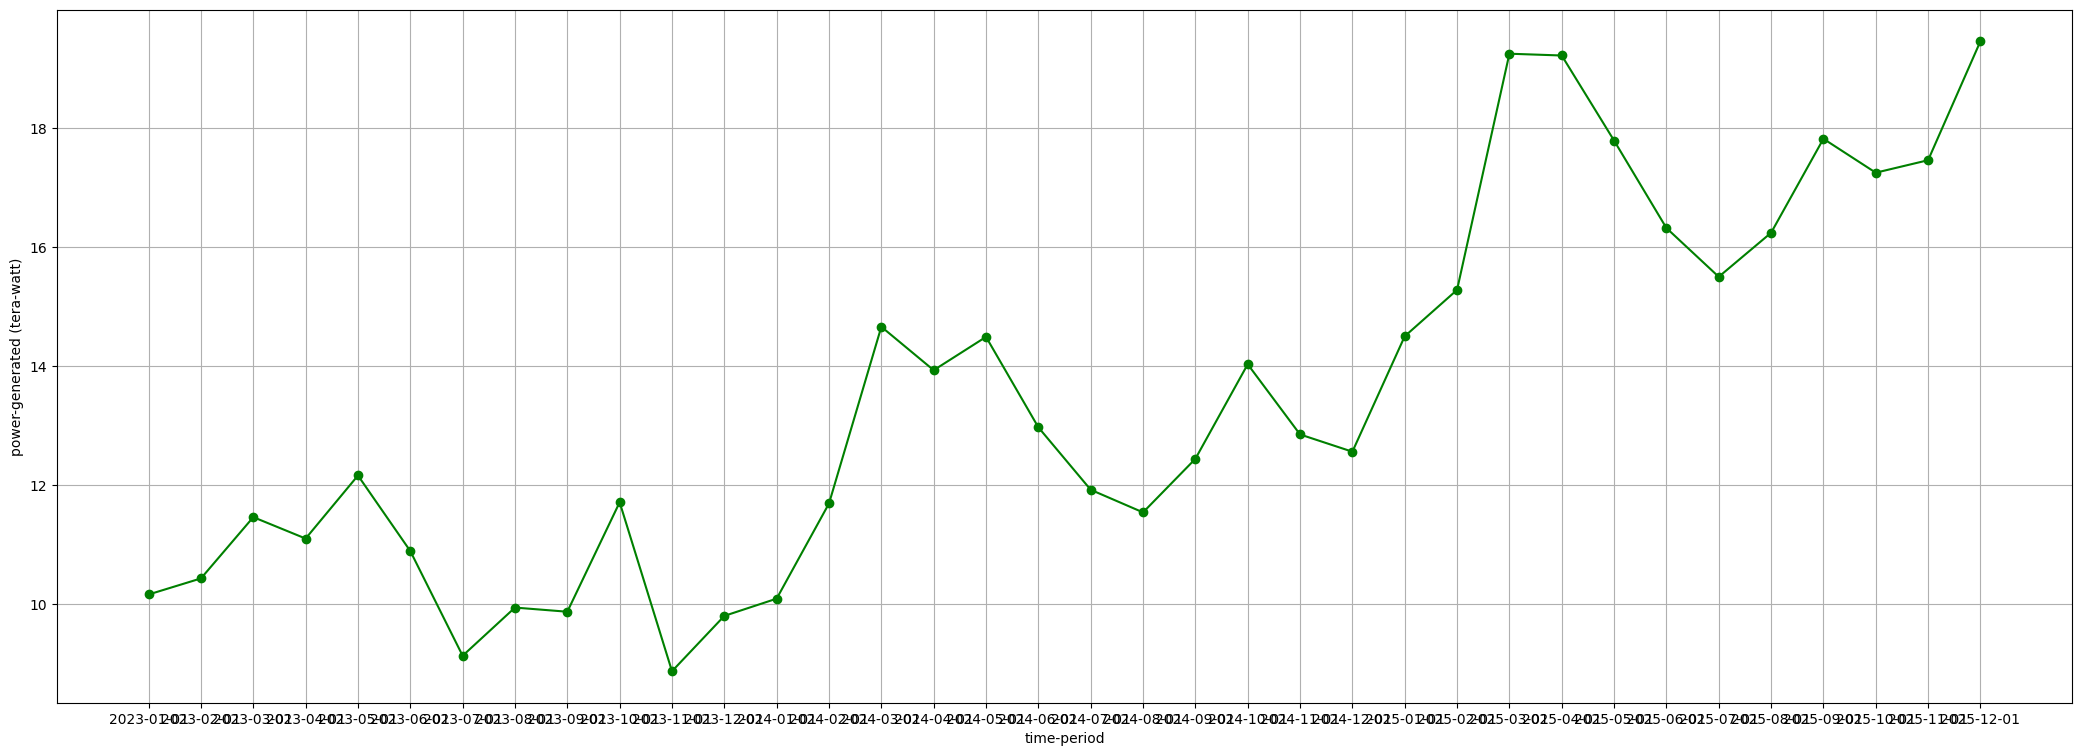

In [21]:
solar_fig = plt.figure()
solar_fig.set_figwidth(26)
solar_fig.set_figheight(9)

x_axis_points = numpy.array(solar_df['date'])
y_axis_points = numpy.array(solar_df['generation_twh'])

plt.xlabel('time-period')
plt.ylabel('power-generated (tera-watt)')

# plt.bar(x_axis_points, y_axis_points)
plt.plot(x_axis_points, y_axis_points, color='green', marker = 'o')
plt.grid()


In [37]:
# total_wind_energy_generation_2023 = power_df.loc[(power_df['series'] == 'Wind') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year== 2023)]
# print(total_wind_energy_generation_2023['generation_twh'].sum())

# total_wind_energy_generation_2024 = power_df.loc[(power_df['series'] == 'Wind') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2024)]
# print(total_wind_energy_generation_2024['generation_twh'].sum())

total_wind_energy_generation_2026 = power_df.loc[(power_df['series'] == 'Wind') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2026)]
print(total_wind_energy_generation_2026['generation_twh'].sum())

24.9


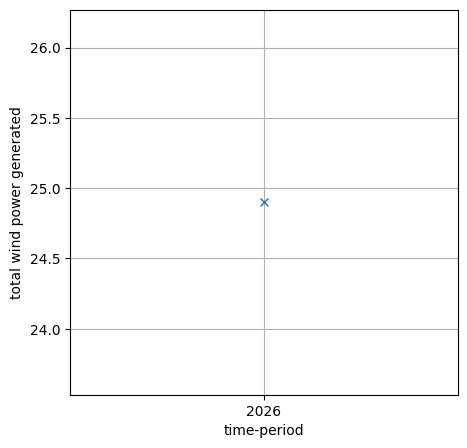

In [38]:
total_wind_power_fig = plt.figure()
total_wind_power_fig.set_figwidth(5)
total_wind_power_fig.set_figheight(5)

x_axis_points = numpy.array(['2026'])
y_axis_points = numpy.array([total_wind_energy_generation_2026['generation_twh'].sum()])

plt.xlabel('time-period')
plt.ylabel('total wind power generated')

plt.plot(x_axis_points, y_axis_points, marker = 'x')
plt.grid()
#plt.bar(x_axis_points, y_axis_points, color='green', width=0.15)


In [39]:
gas_df = power_df.loc[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0)]
print(gas_df[['entity', 'entity_code', 'date', 'series', 'generation_twh']])
print(statistics.stdev(gas_df['generation_twh']))

   entity entity_code        date series  generation_twh
8   India         IND  2025-12-01    Gas            1.98
17  India         IND  2026-01-01    Gas            1.80
26  India         IND  2026-02-01    Gas            1.69
37  India         IND  2026-03-01    Gas            1.57
42  India         IND  2026-04-01    Gas            2.16
0.23398717913595185


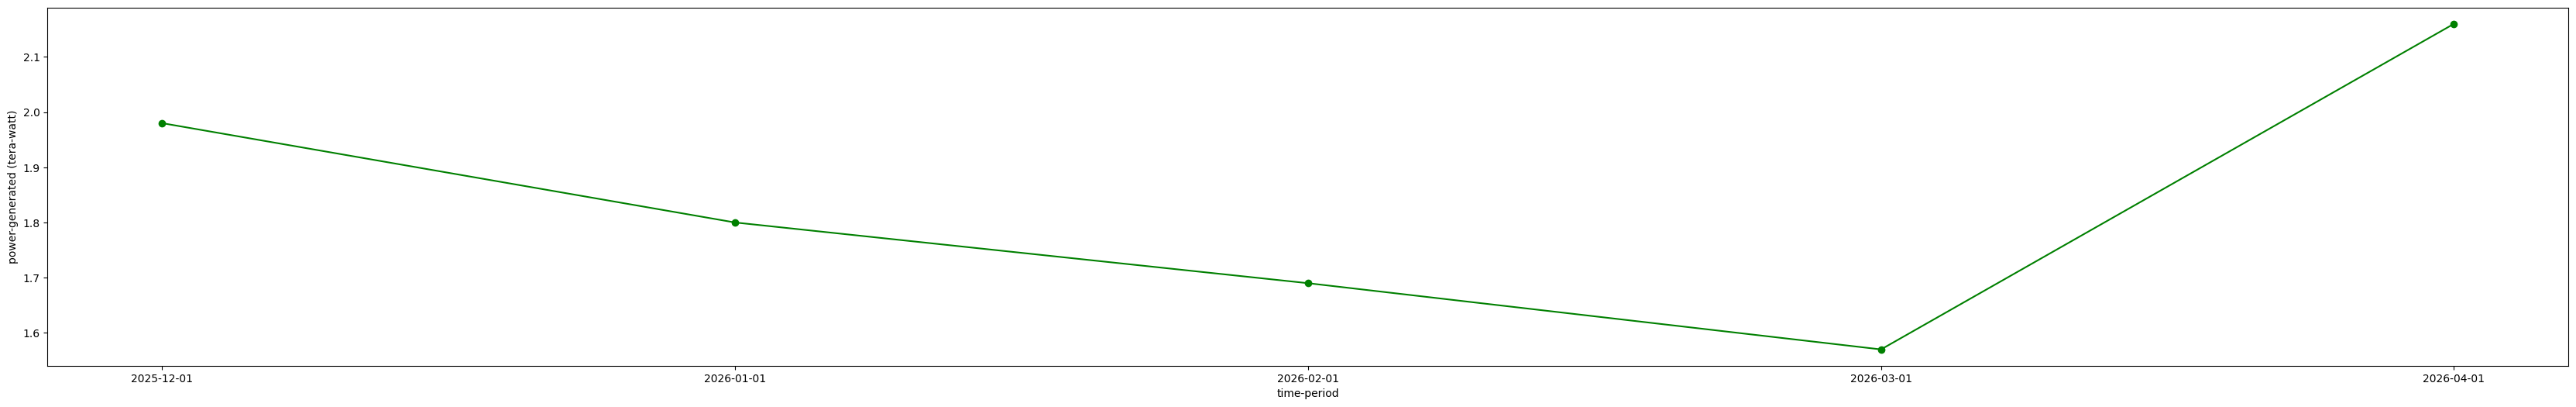

In [40]:
gas_fig = plt.figure()
gas_fig.set_figwidth(42)
gas_fig.set_figheight(6)

x_axis_points = numpy.array(gas_df['date'])
y_axis_points = numpy.array(gas_df['generation_twh'])

plt.xlabel('time-period')
plt.ylabel('power-generated (tera-watt)')

# plt.bar(x_axis_points, y_axis_points)
plt.plot(x_axis_points, y_axis_points, color='green', marker='o')

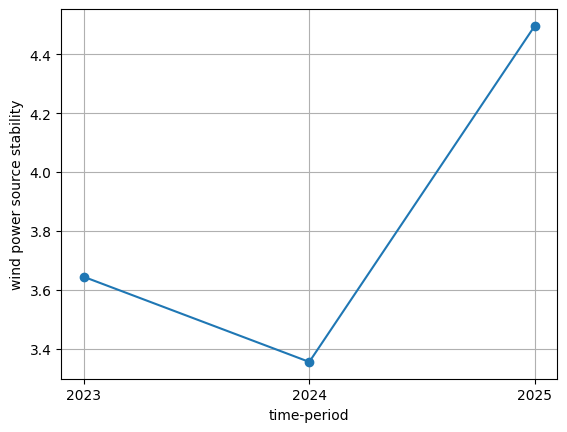

In [18]:
wind_power_variance_2023 = statistics.stdev(total_wind_energy_generation_2023['generation_twh'])
wind_power_variance_2024 = statistics.stdev(total_wind_energy_generation_2024['generation_twh'])
wind_power_variance_2025 = statistics.stdev(total_wind_energy_generation_2025['generation_twh'])

x_axis_points = numpy.array(['2023', '2024', '2025'])
y_axis_points = numpy.array([wind_power_variance_2023,wind_power_variance_2024,wind_power_variance_2025])

plt.xlabel('time-period')
plt.ylabel('wind power source stability')

plt.plot(x_axis_points, y_axis_points, marker = 'o')
plt.grid()
plt.show()

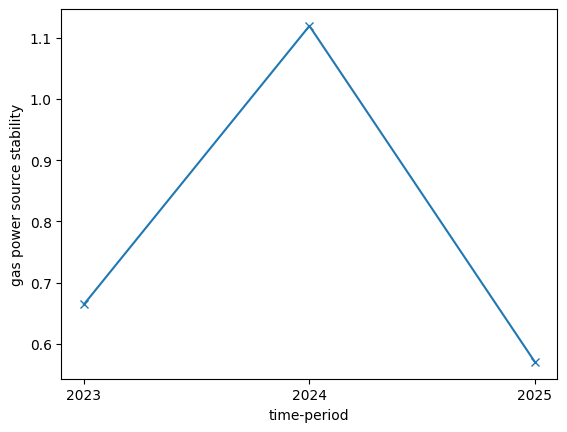

In [19]:
total_gas_energy_generation_2023 = power_df.loc[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year== 2023)]
total_gas_energy_generation_2024 = power_df.loc[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2024)]
total_gas_energy_generation_2025 = power_df.loc[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2025)]

gas_power_variance_2023 = statistics.stdev(total_gas_energy_generation_2023['generation_twh'])
gas_power_variance_2024 = statistics.stdev(total_gas_energy_generation_2024['generation_twh'])
gas_power_variance_2025 = statistics.stdev(total_gas_energy_generation_2025['generation_twh'])

x_axis_points = numpy.array(['2023','2024','2025'])
y_axis_points = numpy.array([gas_power_variance_2023,gas_power_variance_2024, gas_power_variance_2025])

plt.xlabel('time-period')
plt.ylabel('gas power source stability')

plt.plot(x_axis_points, y_axis_points, marker='x')
plt.show()

2.45
2.34
1.65


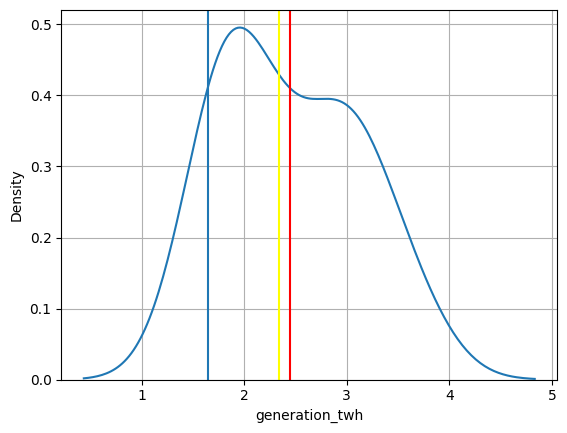

In [20]:
gas_power_generation_2023 = power_df[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2023)]
# print(gas_power_generation_2023['generation_twh'])
gas_power_mean_2023 = statistics.mean(gas_power_generation_2023['generation_twh'])
gas_power_median_2023 = statistics.median(sorted(gas_power_generation_2023['generation_twh']))
gas_power_mode_2023 = statistics.mode(sorted(gas_power_generation_2023['generation_twh']))

print(gas_power_mean_2023)
print(gas_power_median_2023)
print(gas_power_mode_2023)


sns.kdeplot(gas_power_generation_2023['generation_twh'])
plt.axvline(gas_power_mean_2023, label="Mean", color="red")
plt.axvline(gas_power_median_2023, label = "Median", color="yellow")
plt.axvline(gas_power_mode_2023, label = "Mode")
plt.grid()
plt.show()


In [21]:
# print(gas_df[['date', 'generation_twh']])
# print("Gas Year Wise generation")
# print(gas_df.groupby(pd.DatetimeIndex(gas_df['date']).year)['generation_twh'].sum())

# print("\n")

# print("Coal power year wise Generation")
# print(thermal_df.groupby(pd.DatetimeIndex(thermal_df['date']).year)['generation_twh'].sum())

# print("\n")

# print("Wind energy year wise generation")
# print(wind_df.groupby(pd.DatetimeIndex(wind_df['date']).year)['generation_twh'].sum())

# print("\n")
# print("Solar power generation year wise")
# print(solar_df.groupby(pd.DatetimeIndex(solar_df['date']).year)['generation_twh'].sum())

# date_df = pd.DatetimeIndex(power_df['date']).year
# print(date_df)
# series_df = power_df['series'].unique()

print(power_df.groupby([pd.DatetimeIndex(power_df['date']).year, power_df['series']])['generation_twh'].sum())


date  series          
2023  Bioenergy             14.93
      Coal                1265.11
      Gas                   29.40
      Hydro                148.83
      Net imports           -9.81
      Nuclear               48.20
      Other fossil           0.38
      Other renewables       2.67
      Solar                125.52
      Wind                  82.10
2024  Bioenergy             13.48
      Coal                1328.21
      Gas                   33.91
      Hydro                155.97
      Net imports          -11.59
      Nuclear               54.70
      Other fossil           0.42
      Other renewables       2.86
      Solar                153.17
      Wind                  81.56
2025  Bioenergy             14.27
      Coal                1284.46
      Gas                   26.01
      Hydro                177.41
      Net imports           -8.07
      Nuclear               53.83
      Other fossil           0.43
      Other renewables       2.92
      Solar              

In [22]:
# kurtosis(gas_power_generation_2023['generation_twh'] ,axis = 0, fisher=True, bias=True)

gas_power_generation_2024 = power_df[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2024)]
kurtosis(gas_power_generation_2024['generation_twh'])

np.float64(-0.05197054621461339)

In [23]:
gas_power_generation_2025 = power_df[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2025)]
gas_power_generation_2024 = power_df[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2024)]
gas_power_generation_2023 = power_df[(power_df['series'] == 'Gas') & (power_df['generation_twh'] != 0) & (pd.DatetimeIndex(power_df['date']).year == 2023)]

print(kurtosis(gas_power_generation_2025['generation_twh']))
print(kurtosis(gas_power_generation_2024['generation_twh']))
print(kurtosis(gas_power_generation_2023['generation_twh']))

-1.1459310203217896
-0.05197054621461339
-1.2658498276145562


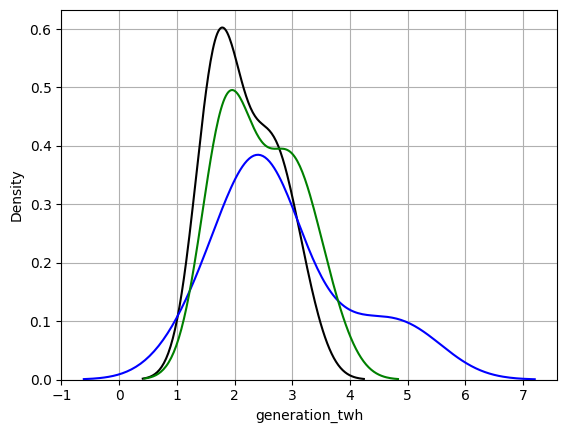

In [24]:
sns.kdeplot(gas_power_generation_2025['generation_twh'], color="black")
sns.kdeplot(gas_power_generation_2024['generation_twh'], color = "blue")
sns.kdeplot(gas_power_generation_2023['generation_twh'], color= "green")
plt.grid()